In [ ]:
import seaborn as sns
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn

df = load_digits()
batch_size = 64

torch.random.manual_seed(32)

In [ ]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


train_dataset_full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)


train_size = int(0.83 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])


batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


2 torch.Size([1, 28, 28])


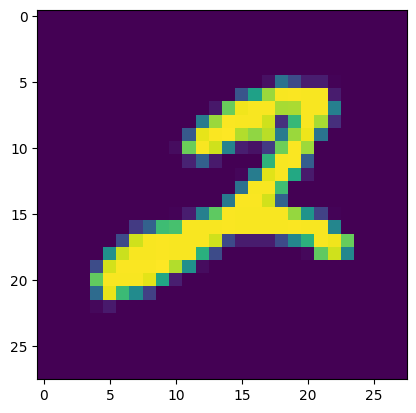

In [ ]:

# Get the first item
image, label = train_dataset[0]
print(label,image.shape)
plt.imshow(image.reshape(28,28))


In [ ]:
class CNNModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(16 * 7 * 7, 120),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(120, 60),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(60, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [ ]:
print((4*7*7*2)/3)

130.66666666666666


In [ ]:
train_loss = []
val_loss = []
epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # pick GPU if available

model = CNNModel().to(device)  # move model to GPU
criterion = torch.nn.CrossEntropyLoss()
optim = torch.optim.Adam(params=model.parameters(), lr=0.001,weight_decay=1e-4)

for epoch in range(epochs):
    # ---- Training ----
    model.train()
    epoch_train_loss = 0.0
    for image, labels in train_loader:
        image, labels = image.to(device), labels.to(device)  # move batch to GPU

        optim.zero_grad()
        logits = model(image)
        loss = criterion(logits, labels)

        loss.backward()
        optim.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_loss.append(avg_train_loss)

    # ---- Validation ----
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for image, labels in val_loader:
            image, labels = image.to(device), labels.to(device)
            logits = model(image)
            loss = criterion(logits, labels)
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_loss.append(avg_val_loss)

    # ---- Logging ----
    if epoch % 5 == 0:  # print every 5 epochs
        print(f"Epoch: {epoch}, "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {avg_val_loss:.4f}")


Epoch: 0, Train Loss: 0.4005, Val Loss: 0.0962
Epoch: 5, Train Loss: 0.0656, Val Loss: 0.0552
Epoch: 10, Train Loss: 0.0449, Val Loss: 0.0501
Epoch: 15, Train Loss: 0.0357, Val Loss: 0.0467
Epoch: 20, Train Loss: 0.0300, Val Loss: 0.0507
Epoch: 25, Train Loss: 0.0270, Val Loss: 0.0463
Epoch: 30, Train Loss: 0.0281, Val Loss: 0.0409
Epoch: 35, Train Loss: 0.0215, Val Loss: 0.0529
Epoch: 40, Train Loss: 0.0219, Val Loss: 0.0413
Epoch: 45, Train Loss: 0.0210, Val Loss: 0.0484


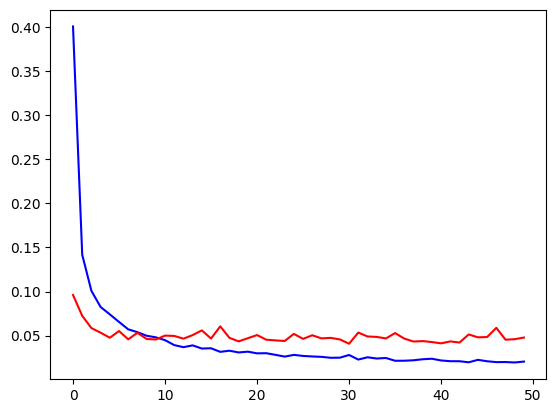

In [ ]:

plt.plot([i for i in range(50)],train_loss,c='b')
plt.plot([i for i in range(50)],val_loss,c='r')

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)  # make sure model is on correct device
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)  # <-- move batch to device
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())   # move back to CPU for sklearn
        all_labels.extend(yb.cpu().numpy())

# --- Metrics ---
cm = confusion_matrix(all_labels, all_preds)
acc = accuracy_score(all_labels, all_preds)
report = classification_report(all_labels, all_preds, digits=4)

print("Confusion Matrix:\n", cm)
print(f"\nAccuracy: {acc:.4f}")
print("\nClassification Report:\n", report)


Confusion Matrix:
 [[ 977    0    1    0    0    0    1    1    0    0]
 [   0 1132    2    1    0    0    0    0    0    0]
 [   0    0 1026    1    0    0    0    3    2    0]
 [   0    0    2 1003    0    3    0    1    1    0]
 [   0    0    1    0  972    0    2    1    1    5]
 [   1    0    0    9    0  880    2    0    0    0]
 [   3    1    1    0    1    3  946    0    3    0]
 [   0    1    3    0    1    0    0 1015    1    7]
 [   2    1    1    0    1    1    0    1  965    2]
 [   2    0    1    2    2    2    0    5    4  991]]

Accuracy: 0.9907

Classification Report:
               precision    recall  f1-score   support

           0     0.9919    0.9969    0.9944       980
           1     0.9974    0.9974    0.9974      1135
           2     0.9884    0.9942    0.9913      1032
           3     0.9872    0.9931    0.9901      1010
           4     0.9949    0.9898    0.9923       982
           5     0.9899    0.9865    0.9882       892
           6     0.9947    0